In [1]:
import pandas as pd

caminho_dados = 'https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv'

dados = pd.read_csv(caminho_dados)

dados.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


In [2]:
#checar tamanho da base
print(dados.shape)

(2500, 19)


In [3]:
#checar informações prévias e característica das colunas da base
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [4]:
dados.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [5]:
#como não foram identificados valores nulos, o próximo passo é identificar possíveis linhas duplicadas
dados.duplicated().sum()

np.int64(0)

In [6]:
#confirmar que o identificador único dos pedidos não possui duplicatas
dados.duplicated(['order_id']).sum()

np.int64(0)

In [7]:
#verificar a quantidade de clientes únicos presentes na base
dados['customer_id'].nunique()

2500

In [8]:
#avaliar estatísticas iniciais, onde o .T serve para transpor a tabela e facilitar a leitura na tela
dados.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


In [9]:
#vale dar uma olhada breve em como estão também as estatísticas da única variável categórica
dados.describe(exclude='number')

,customer_region
count,2500
unique,5
top,Sul
freq,521


In [10]:
#um tópico interessante de se entender é quantos clientes voltaram a comprar após 30 dias
print(dados['repeat_purchase_30d'].value_counts())
print(dados['repeat_purchase_30d'].value_counts(normalize=True) * 100)

repeat_purchase_30d
0    2282
1     218
Name: count, dtype: int64
repeat_purchase_30d
0    91.28
1     8.72
Name: proportion, dtype: float64


In [11]:
#de acordo com as estatísticas e demais avaliações, as colunas não aparentam possuir valores discrepantes ou que não fazem sentido num primeiro momento. 
#Porém, existem alguns pontos de atenção:
#  -o tempo médio de resolução dos problemas gira em torno de 5 dias, o que pode se considerar um tempo relativamente grande;
#  -o score interno de satisfação do cliente tem uma média muito baixa (abaixo de 3 num máximo de 10), o que pode indicar uma falha na execução operacional;
#  -outro que possui média baixa é o próprio NPS, com uma nota média abaixo de 5 num valor máximo de 10;
#  -vale destacar ainda a identificação que mais de 90% dos clientes da base não voltaram a comprar 30 dias após o pedido.


In [12]:
#seguindo com a ideia de avaliar o NPS, uma boa prática agora seria dividir os clientes em grupos de acordo com essa variável
def categorizar_nps(score):
    if score >= 9.0:
        return 'Promotor'
    elif score >= 7.0:
        return 'Neutro'
    else:
        return 'Detrator'

dados['nps_group'] = dados['nps_score'].apply(categorizar_nps)

print(dados['nps_group'].value_counts())
print(dados['nps_group'].value_counts(normalize=True) * 100)

nps_group
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64
nps_group
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64


In [13]:
#o retorno para cada divisão de grupos do NPS confirma a suspeita anterior de que a maioria de clientes da nossa base não aparenta satisfação com os serviços prestados,
#visto que 84,36% dos clientes foram classificados como detratores (NPS abaixo de 7) e apenas 4,40% como promotores (NPS acima ou igual a 9)

In [14]:
#temos alguns indicadores na nossa base que podem nos indicar o caminho do problema para um NPS tão baixo na maioria dos clientes. 
#Vamos avalia-los separadamente na sequência
colunas_operacionais = [
    'delivery_time_days'
  , 'delivery_delay_days'
  , 'delivery_attempts'
  , 'customer_service_contacts'
  , 'resolution_time_days'
  , 'complaints_count'
  ]

media_por_grupo = dados.groupby('nps_group')[colunas_operacionais].mean()
media_por_grupo

,delivery_time_days,delivery_delay_days,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count
nps_group,,,,,,
Detrator,7.994310,2.414889,1.997155,1.632053,5.694642,4.442390
Neutro,8.263345,1.053381,2.010676,1.007117,4.615658,2.693950
Promotor,7.936364,0.718182,2.154545,0.672727,3.700000,2.272727


In [15]:
#Vamos avaliar a delivery_delay_days que apresentou uma variação grande entre um cliente considerado detrator e um promotor
nps_por_atraso = dados.groupby('delivery_delay_days')['nps_score'].agg(['mean', 'count']).reset_index()
nps_por_atraso.columns = ['dias_de_atraso', 'nps_medio', 'qtd_pedidos']

nps_por_atraso

,dias_de_atraso,nps_medio,qtd_pedidos
0,0,6.856679,277
1,1,5.546179,615
2,2,4.580186,646
3,3,3.436762,525
4,4,2.444444,270
5,5,1.481034,116
6,6,1.097059,34
7,7,0.292857,14
8,8,0.000000,3


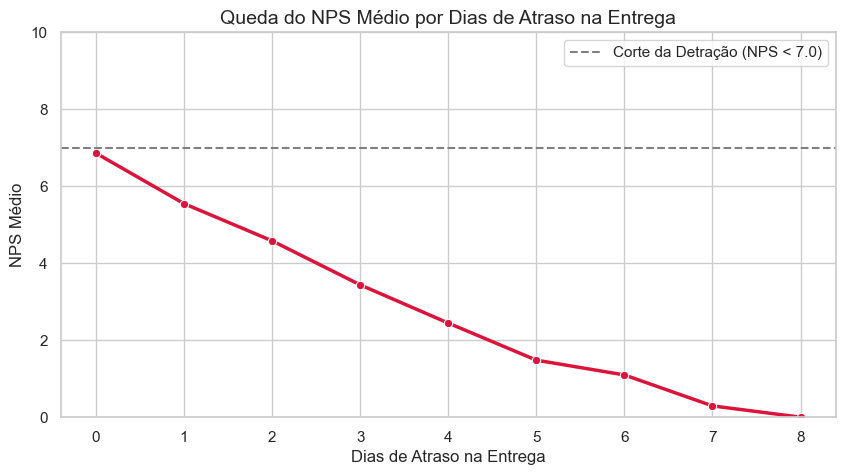

In [28]:
#agora vale gerar um gráfico para visualizar o quanto os dias de atraso impactam na queda do NPS
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Criar gráfico de linha para o atraso
sns.lineplot(
    data=nps_por_atraso, 
    x='dias_de_atraso', 
    y='nps_medio', 
    marker='o', 
    color='crimson', 
    linewidth=2.5
)

# Adicionar uma linha tracejada horizontal no NPS = 7 (limite para ser Neutro/Promotor)
plt.axhline(y=7.0, color='gray', linestyle='--', label='Corte da Detração (NPS < 7.0)')

# Títulos e rótulos
plt.title('Queda do NPS Médio por Dias de Atraso na Entrega', fontsize=14)
plt.xlabel('Dias de Atraso na Entrega', fontsize=12)
plt.ylabel('NPS Médio', fontsize=12)
plt.ylim(0, 10)
plt.legend()

plt.savefig('../reports/figures/queda_do_nps_medio_por_dias_de_atraso.png', dpi=300, bbox_inches='tight')

plt.show()

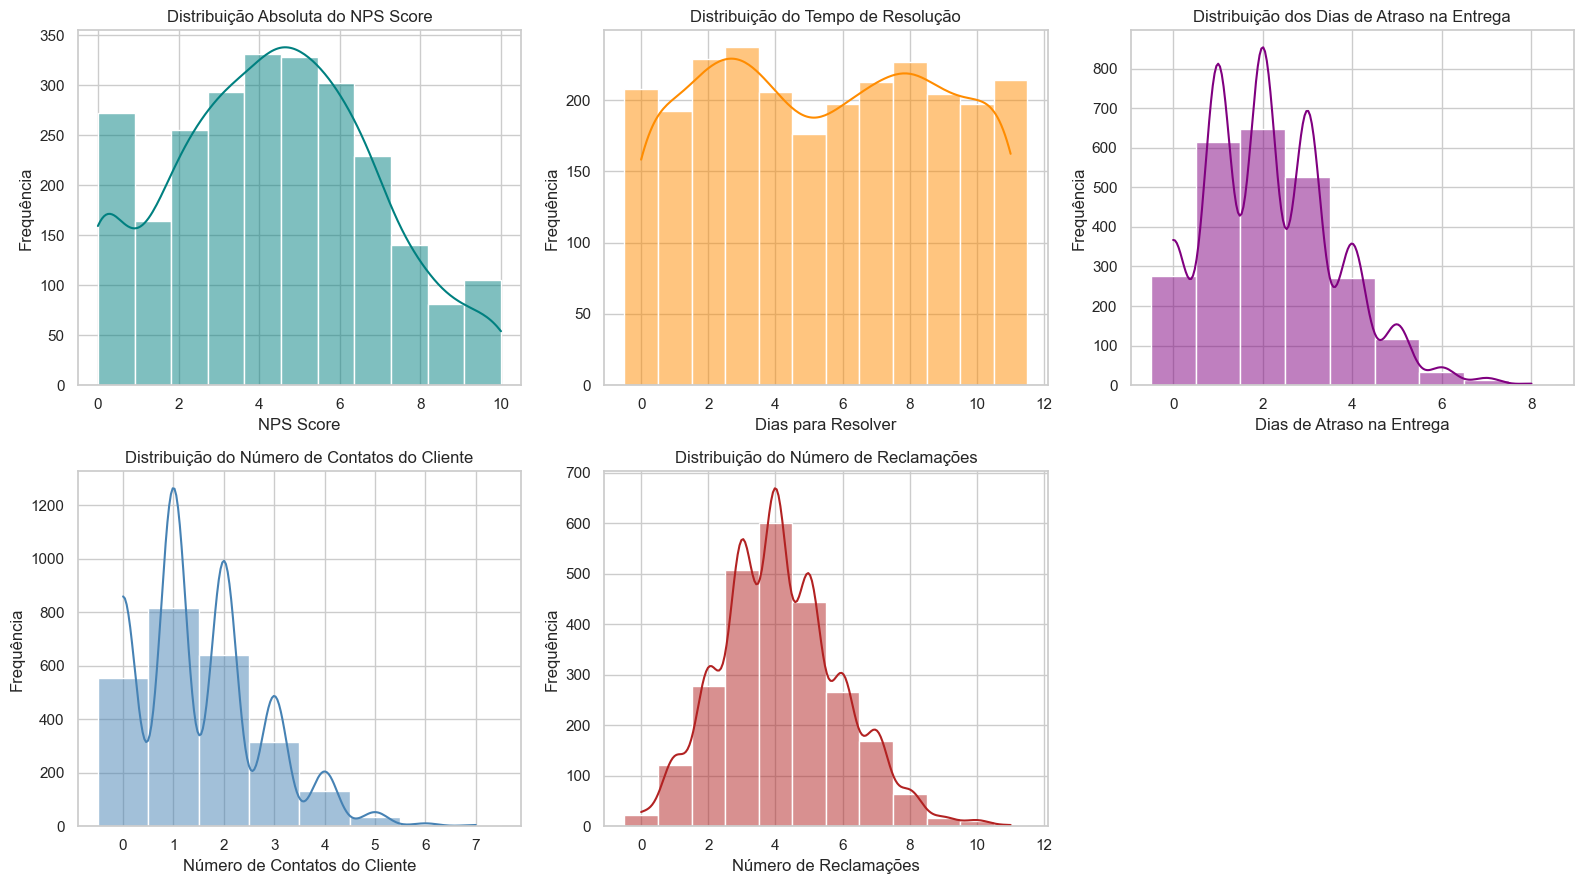

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Distribuição das notas do NPS
sns.histplot(dados['nps_score'], kde=True, bins=11, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição Absoluta do NPS Score')
axes[0, 0].set_xlabel('NPS Score')
axes[0, 0].set_ylabel('Frequência')

# 2. Distribuição do Tempo de Resolução
sns.histplot(dados['resolution_time_days'], discrete=True, kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição do Tempo de Resolução')
axes[0, 1].set_xlabel('Dias para Resolver')
axes[0, 1].set_ylabel('Frequência')

# 3. Distribuição do Valor do Frete
sns.histplot(dados['delivery_delay_days'], discrete=True, kde=True, color='purple', ax=axes[0, 2])
axes[0, 2].set_title('Distribuição dos Dias de Atraso na Entrega')
axes[0, 2].set_xlabel('Dias de Atraso na Entrega')
axes[0, 2].set_ylabel('Frequência')

# 4. Distribuição do Número de Contatos do Cliente
sns.histplot(dados['customer_service_contacts'], discrete=True, kde=True, color='steelblue', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição do Número de Contatos do Cliente')
axes[1, 0].set_xlabel('Número de Contatos do Cliente')
axes[1, 0].set_ylabel('Frequência')

# 5. Distribuição do Número de Reclamações
sns.histplot(dados['complaints_count'], discrete=True, kde=True, color='firebrick', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição do Número de Reclamações')
axes[1, 1].set_xlabel('Número de Reclamações')
axes[1, 1].set_ylabel('Frequência')

# Remove o espaço vazio do canto inferior direito
fig.delaxes(axes[1, 2])

plt.tight_layout()

plt.savefig('../reports/figures/distribuicoes_operacionais.png', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
# Vamos avaliar quem teve 0 dias de atraso, pois se repararmos, mesmo quem teve nenhum atraso a nota foi relativamente baixa (menor que 7)
atraso_zero = dados[dados['delivery_delay_days'] == 0]

# Ver a média das outras variáveis de fricção nesse grupo específico
print(atraso_zero[['customer_service_contacts', 'resolution_time_days', 'complaints_count', 'csat_internal_score', 'nps_score']].mean())

customer_service_contacts    1.545126
resolution_time_days         5.685921
complaints_count             2.956679
csat_internal_score          4.774729
nps_score                    6.856679
dtype: float64


In [19]:
# pelo rsultado acima podemos notar que, apesar de não ocorrerem atrasos para esses clientes, eles registram quase 3 reclamações em média e precisam esperar 5,68 dias para terem 
# seus problemas resolvidos. Ou seja, a entrega no prazo evita a catástrofe total, mas não salva de uma valiação ruim visto os problemas com o pós-venda

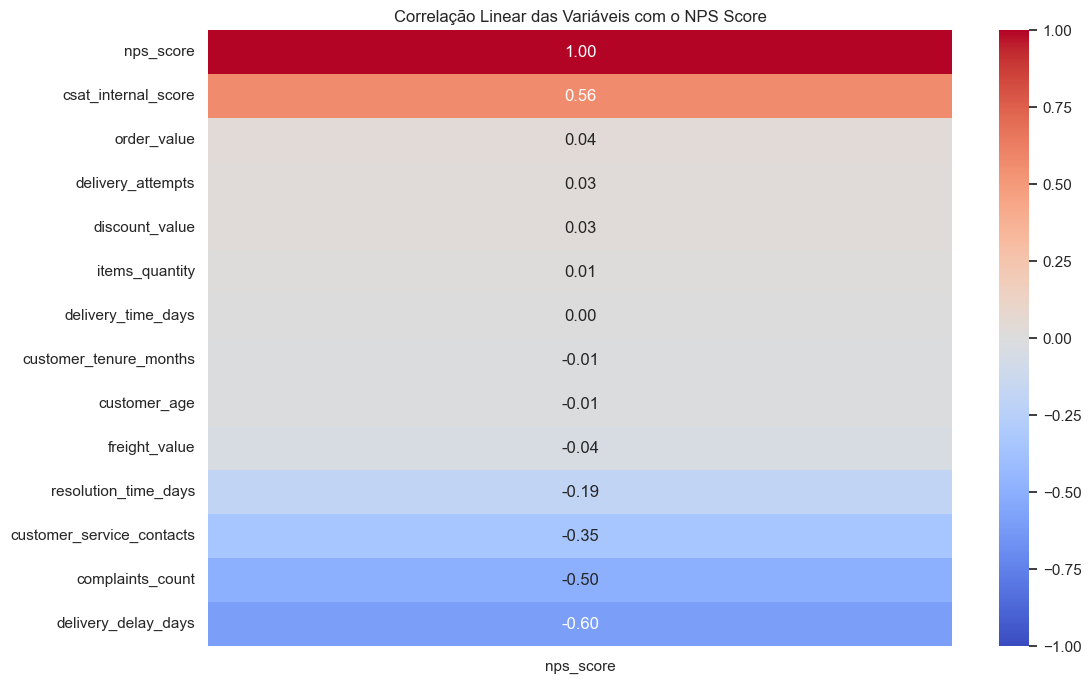

In [32]:
# Cabe agora gerar um mapa de calor de correlação entre as variáveis, para ver se a nossa análise até aqui está coerente
# Selecionar variáveis numéricas relevantes (remover IDs)
cols_analise = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'csat_internal_score', 'nps_score'
]

plt.figure(figsize=(12, 8))
correlation_matrix = dados[cols_analise].corr()

# Desenhar o heatmap focando na relação das variáveis com o NPS
sns.heatmap(correlation_matrix[['nps_score']].sort_values(by='nps_score', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlação Linear das Variáveis com o NPS Score')

plt.savefig('../reports/figures/correlacao_nps.png', dpi=300, bbox_inches='tight')

plt.show()

In [21]:
# sempre bom pontuar que correlação não é causalidade. Posto isso, avaliando o mapa de calor, vemos que o atraso nas entregas, o número de reclamações, o número 
# de contatos do cliente com o atendimento e o tempo de resolução de problemas, tendem a ser os principais responsáveis pelas avaliações baixas de NPS. 
# Isso indica que o ponto de ruptura passa por essas 4 variáveis intrínsecas ao negócio, sendo elas complementares para explicar o problema a ser resolvido

In [22]:
# Vale dar uma olhada se o perfil dos clientes impacta nessa avaliação baixa
perfil_clientes = dados.groupby('nps_group')[[
    'customer_age', 
    'customer_tenure_months', 
    'order_value', 
    'delivery_delay_days', 
    'customer_service_contacts', 
    'complaints_count'
]].mean().reindex(['Promotor', 'Neutro', 'Detrator'])

perfil_clientes

,customer_age,customer_tenure_months,order_value,delivery_delay_days,customer_service_contacts,complaints_count
nps_group,,,,,,
Promotor,43.627273,63.000000,468.084182,0.718182,0.672727,2.272727
Neutro,43.252669,59.832740,458.171779,1.053381,1.007117,2.693950
Detrator,43.403035,61.433381,429.309540,2.414889,1.632053,4.442390


In [23]:
# o perfil dos clientes é praticamente o mesmo, o que indica que de fato o problema gira em torno de uma experiência operacional

In [24]:
# Para finalizar, vamos averiguar que não estamos deixando passar nenhum viés de região
regiao_analysis = dados.groupby('customer_region').agg(
    qtd_pedidos=('order_id', 'count'),
    nps_medio=('nps_score', 'mean'),
    atraso_medio=('delivery_delay_days', 'mean'),
    reclamacoes_medias=('complaints_count', 'mean')
).reset_index()

regiao_analysis

,customer_region,qtd_pedidos,nps_medio,atraso_medio,reclamacoes_medias
0,Centro-Oeste,468,4.209829,2.222222,4.177350
1,Nordeste,485,4.421649,2.185567,4.162887
2,Norte,506,4.382609,2.144269,4.110672
3,Sudeste,520,4.373846,2.217308,4.242308
4,Sul,521,4.490979,2.168906,4.061420


In [25]:
# também não existem problemas notórios a primeira vista que sejam relativos a localização dos clientes